# Pandemic Supply Chain DES Exploration

Interactive exploration of the Discrete Event Simulation system for pandemic modeling.

## Components
- **DES Core**: Event scheduling, resources, timeouts
- **Supply Chain**: PPE, reagents, healthcare workers
- **Social Network**: 100-person Watts-Strogatz graph
- **Disease Model**: SEIR state machine with transmission

In [ ]:
%matplotlib inline
import importlib
import sys

sys.path.insert(0, "/Users/danielgoodwin/Work/personal/pandemic_modeling")
import des_system.config
importlib.reload(des_system.config)

import random
import matplotlib.pyplot as plt

import numpy as np

from config import (
    SimulationConfig, 
    SupplyChainConfig, 
    NetworkConfig, 
    DiseaseConfig,
    high_transmission_config,
    low_resources_config,
    elderly_population_config,
    dense_network_config,
)
from simulation import PandemicSimulation, run_simulation
from social_network import SocialNetwork, DiseaseState
from des_core import Environment

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("DES system loaded successfully!")

ModuleNotFoundError: No module named 'des_system'

---
## 1. Configuration Overview

All parameters are centralized in config objects. Let's explore them.

In [ ]:
# Create default config and display it
config = SimulationConfig(random_seed=42)
print(config.summary())


╔══════════════════════════════════════════════════════════════╗
║                    SIMULATION CONFIGURATION                   ║
╠══════════════════════════════════════════════════════════════╣
║ POPULATION                                                    ║
║   People:  100  │  Age range: 18-80                  ║
║   Avg contacts: 6  │  Rewire prob: 30.0%                ║
╠══════════════════════════════════════════════════════════════╣
║ DISEASE PARAMETERS                                            ║
║   Transmission prob: 15.0%                                 ║
║   Exposure period: 3.0 days                                ║
║   Infectious period: 2.0 days                              ║
║   Symptomatic period: 7.0 days                             ║
║   Hospitalization: 15.0%  │  Mortality: 2.0%         ║
║   Age risk threshold: 60  │  Multiplier: 2.0x          ║
╠══════════════════════════════════════════════════════════════╣
║ SUPPLY CHAIN                                          

In [ ]:
print("=== DISEASE CONFIG ===")
for field, value in config.disease.__dict__.items():
    # if field != "UNITS":
    unit = config.disease.get_unit(field)
    print(f"  {field}: {value} {unit}")
          
print("\n=== SUPPLY CHAIN CONFIG ===")
for field, value in config.supply_chain.__dict__.items():
    if not callable(value) and not field.startswith('_'):
        print(f"  {field}: {value}")

print("\n=== NETWORK CONFIG ===")
for field, value in config.network.__dict__.items():
    print(f"  {field}: {value}")

=== DISEASE CONFIG ===
  UNITS: {'transmission_prob': 'probability', 'daily_contact_rate': 'fraction/day', 'exposure_period': 'days', 'infectious_period': 'days', 'symptomatic_period': 'days', 'hospital_stay': 'days', 'exposure_cv': 'CV', 'infectious_cv': 'CV', 'symptomatic_cv': 'CV', 'hospital_cv': 'CV', 'min_exposure': 'days', 'min_infectious': 'days', 'min_symptomatic': 'days', 'min_hospital': 'days', 'hospitalization_prob': 'probability', 'mortality_prob': 'probability', 'age_risk_threshold': 'years', 'age_risk_multiplier': 'multiplier'} 
  transmission_prob: 0.15 probability
  daily_contact_rate: 0.5 fraction/day
  exposure_period: 3.0 days
  infectious_period: 2.0 days
  symptomatic_period: 7.0 days
  hospital_stay: 7.0 days
  exposure_cv: 0.2 CV
  infectious_cv: 0.2 CV
  symptomatic_cv: 0.3 CV
  hospital_cv: 0.29 CV
  min_exposure: 1.0 days
  min_infectious: 0.5 days
  min_symptomatic: 2.0 days
  min_hospital: 3.0 days
  hospitalization_prob: 0.15 probability
  mortality_prob: 0

---
## 2. Run Baseline Simulation

In [ ]:
# Run with default config
result = run_simulation(config)
print(result.summary())


╔══════════════════════════════════════════════════════════════╗
║                     SIMULATION RESULTS                        ║
╠══════════════════════════════════════════════════════════════╣
║ EPIDEMIC OUTCOMES                                             ║
║   Total infected:   98 (98.0% of population)           ║
║   Peak active cases:   53 (day 32)                        ║
║   Hospitalizations:   18 (18.4% of infected)          ║
║   Deaths:    0 (0.0% CFR)                              ║
║   Recoveries:   98                                          ║
╠══════════════════════════════════════════════════════════════╣
║ FINAL STATE                                                   ║
║   Susceptible:    2  │  Recovered:   98  │  Deceased:    0  ║
╠══════════════════════════════════════════════════════════════╣
║ SUPPLY CHAIN                                                  ║
║   Final PPE:  15740  │  Min PPE:    100                   ║
║   Final Reagents:  27164  │  Min Reagents:   

---
## 3. Epidemic Curve Visualization

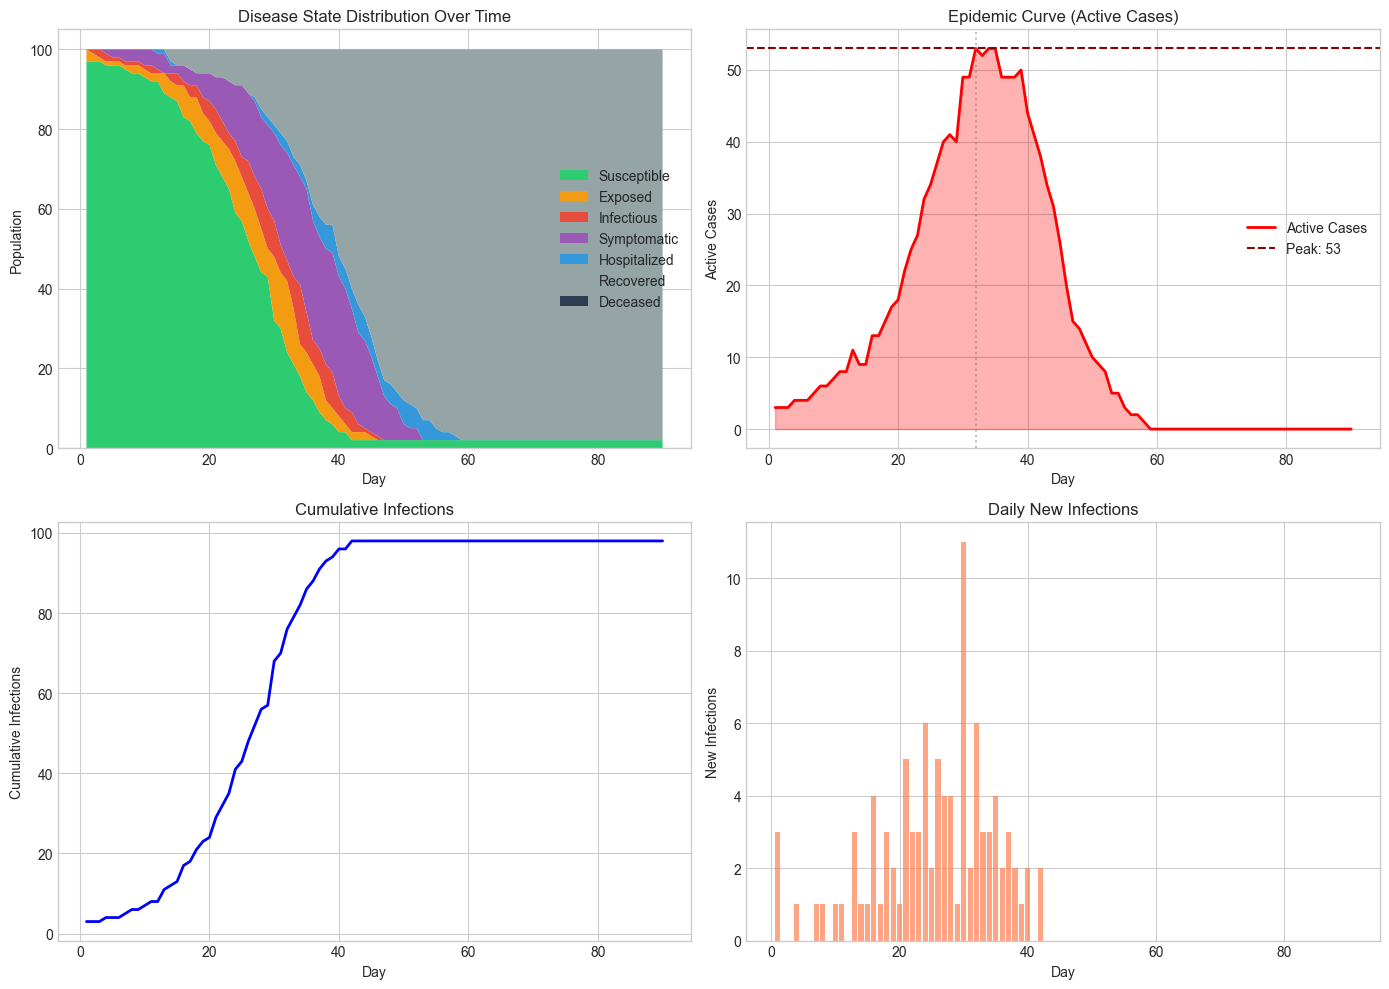

In [ ]:
# Extract time series data
days = [s['time'] for s in result.daily_snapshots]
susceptible = [s['state_counts']['susceptible'] for s in result.daily_snapshots]
exposed = [s['state_counts']['exposed'] for s in result.daily_snapshots]
infectious = [s['state_counts']['infectious'] for s in result.daily_snapshots]
symptomatic = [s['state_counts']['symptomatic'] for s in result.daily_snapshots]
hospitalized = [s['state_counts']['hospitalized'] for s in result.daily_snapshots]
recovered = [s['state_counts']['recovered'] for s in result.daily_snapshots]
deceased = [s['state_counts']['deceased'] for s in result.daily_snapshots]
active = [s['active_cases'] for s in result.daily_snapshots]

# Plot epidemic curve
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SEIR-style curve
ax1 = axes[0, 0]
ax1.stackplot(days, susceptible, exposed, infectious, symptomatic, hospitalized, recovered, deceased,
              labels=['Susceptible', 'Exposed', 'Infectious', 'Symptomatic', 'Hospitalized', 'Recovered', 'Deceased'],
              colors=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#3498db', '#95a5a6', '#2c3e50'])
ax1.set_xlabel('Day')
ax1.set_ylabel('Population')
ax1.set_title('Disease State Distribution Over Time')
ax1.legend(loc='right')

# Active cases curve
ax2 = axes[0, 1]
ax2.fill_between(days, active, alpha=0.3, color='red')
ax2.plot(days, active, 'r-', linewidth=2, label='Active Cases')
ax2.axhline(y=result.peak_active_cases, color='darkred', linestyle='--', label=f'Peak: {result.peak_active_cases}')
ax2.axvline(x=result.peak_day, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Day')
ax2.set_ylabel('Active Cases')
ax2.set_title('Epidemic Curve (Active Cases)')
ax2.legend()

# Cumulative infections
ax3 = axes[1, 0]
cumulative = [s['total_infections'] for s in result.daily_snapshots]
ax3.plot(days, cumulative, 'b-', linewidth=2)
ax3.set_xlabel('Day')
ax3.set_ylabel('Cumulative Infections')
ax3.set_title('Cumulative Infections')

# New infections per day
ax4 = axes[1, 1]
new_infections = [cumulative[i] - cumulative[i-1] if i > 0 else cumulative[0] for i in range(len(cumulative))]
ax4.bar(days, new_infections, color='coral', alpha=0.7)
ax4.set_xlabel('Day')
ax4.set_ylabel('New Infections')
ax4.set_title('Daily New Infections')

plt.tight_layout()
plt.show()

---
## 4. Supply Chain Dynamics

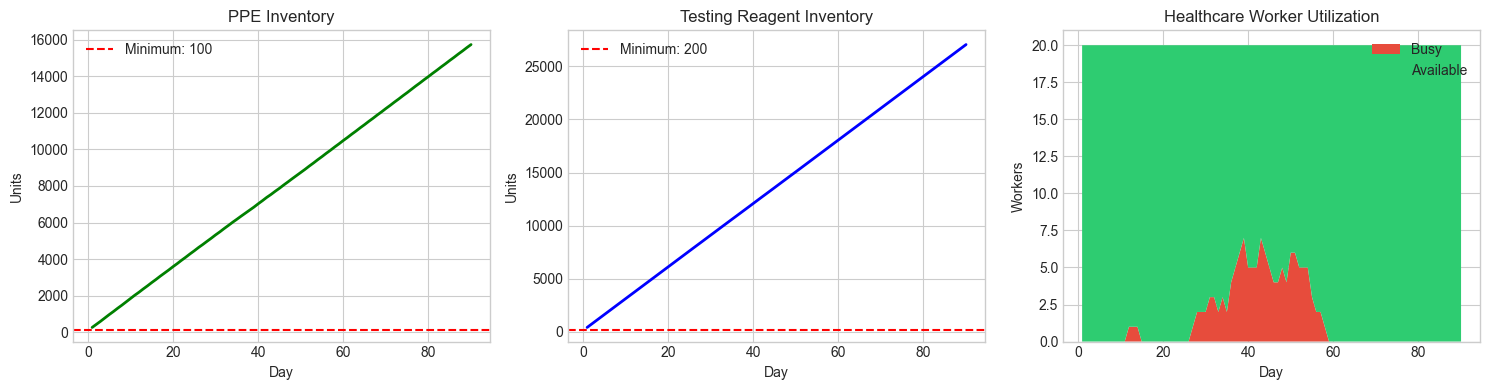

In [ ]:
# Extract supply chain data
ppe_levels = [s['supply_chain']['ppe_level'] for s in result.daily_snapshots]
reagent_levels = [s['supply_chain']['reagent_level'] for s in result.daily_snapshots]
workers_busy = [s['supply_chain']['healthcare_workers_busy'] for s in result.daily_snapshots]
workers_available = [s['supply_chain']['healthcare_workers_available'] for s in result.daily_snapshots]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PPE Inventory
ax1 = axes[0]
ax1.plot(days, ppe_levels, 'g-', linewidth=2)
ax1.axhline(y=result.min_ppe_level, color='red', linestyle='--', label=f'Minimum: {result.min_ppe_level}')
ax1.set_xlabel('Day')
ax1.set_ylabel('Units')
ax1.set_title('PPE Inventory')
ax1.legend()

# Reagent Inventory
ax2 = axes[1]
ax2.plot(days, reagent_levels, 'b-', linewidth=2)
ax2.axhline(y=result.min_reagent_level, color='red', linestyle='--', label=f'Minimum: {result.min_reagent_level}')
ax2.set_xlabel('Day')
ax2.set_ylabel('Units')
ax2.set_title('Testing Reagent Inventory')
ax2.legend()

# Healthcare Worker Utilization
ax3 = axes[2]
ax3.stackplot(days, workers_busy, workers_available, 
              labels=['Busy', 'Available'],
              colors=['#e74c3c', '#2ecc71'])
ax3.set_xlabel('Day')
ax3.set_ylabel('Workers')
ax3.set_title('Healthcare Worker Utilization')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 5. Transmission Chain Analysis

In [ ]:
# Analyze transmission events
events = result.transmission_events

print(f"Total transmission events: {len(events)}")
print(f"Initial seeds: {sum(1 for e in events if e['source_name'] == 'initial_seed')}")

# Age distribution of infected
ages = [e['target_age'] for e in events]
print(f"\nAge of infected:")
print(f"  Min: {min(ages)}, Max: {max(ages)}, Mean: {sum(ages)/len(ages):.1f}")

# Super-spreaders (sources with most infections)
from collections import Counter
sources = Counter(e['source_name'] for e in events if e['source_name'] != 'initial_seed')
print(f"\nTop 5 super-spreaders:")
for name, count in sources.most_common(5):
    print(f"  {name}: {count} infections")

Total transmission events: 98
Initial seeds: 3

Age of infected:
  Min: 18, Max: 80, Mean: 46.5

Top 5 super-spreaders:
  Skyler_20: 4 infections
  Reese_31: 4 infections
  Casey_68: 3 infections
  Kai_69: 3 infections
  Jordan_8: 3 infections


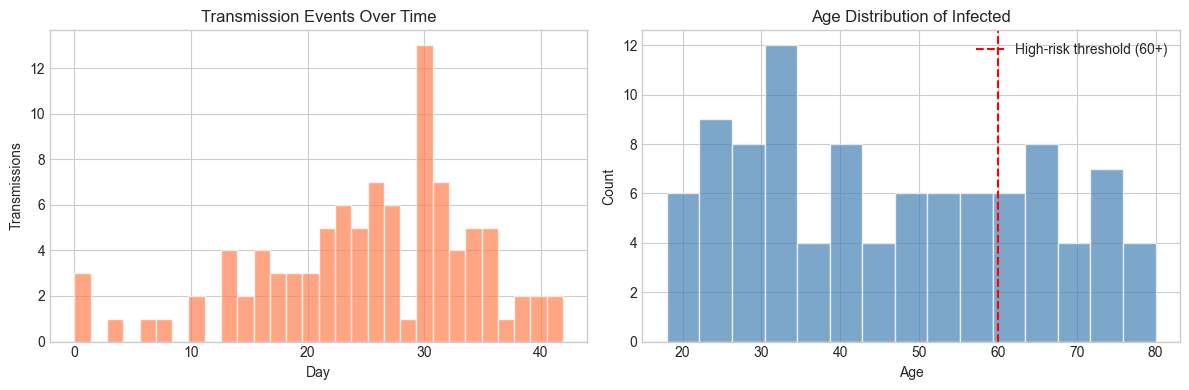

In [ ]:
# Visualize transmission timing
transmission_times = [e['time'] for e in events]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of transmission times
ax1 = axes[0]
ax1.hist(transmission_times, bins=30, color='coral', edgecolor='white', alpha=0.7)
ax1.set_xlabel('Day')
ax1.set_ylabel('Transmissions')
ax1.set_title('Transmission Events Over Time')

# Age distribution of infected
ax2 = axes[1]
ax2.hist(ages, bins=15, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=config.disease.age_risk_threshold, color='red', linestyle='--', 
            label=f'High-risk threshold ({config.disease.age_risk_threshold}+)')
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')
ax2.set_title('Age Distribution of Infected')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 6. Parameter Sensitivity Analysis

Explore how different parameters affect outcomes.

In [ ]:
def run_sensitivity(param_name, values, base_config=None):
    """Run simulations varying a single parameter."""
    results = []
    
    for val in values:
        cfg = base_config or SimulationConfig(random_seed=42)
        
        # Set the parameter
        if '.' in param_name:
            section, field = param_name.split('.')
            setattr(getattr(cfg, section), field, val)
        else:
            setattr(cfg, param_name, val)
        
        result = run_simulation(cfg)
        results.append({
            'value': val,
            'infection_rate': result.infection_rate,
            'peak_cases': result.peak_active_cases,
            'hospitalizations': result.total_hospitalizations,
            'deaths': result.total_deaths,
        })
    
    return results

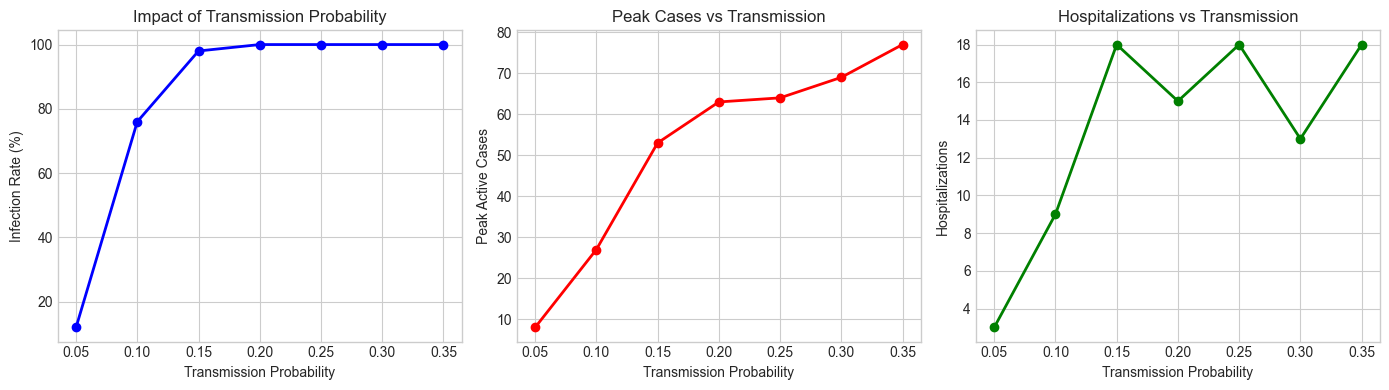

In [ ]:
# Sensitivity: Transmission probability
trans_probs = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
trans_results = run_sensitivity('disease.transmission_prob', trans_probs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
ax1.plot([r['value'] for r in trans_results], [r['infection_rate'] for r in trans_results], 'bo-', linewidth=2)
ax1.set_xlabel('Transmission Probability')
ax1.set_ylabel('Infection Rate (%)')
ax1.set_title('Impact of Transmission Probability')

ax2 = axes[1]
ax2.plot([r['value'] for r in trans_results], [r['peak_cases'] for r in trans_results], 'ro-', linewidth=2)
ax2.set_xlabel('Transmission Probability')
ax2.set_ylabel('Peak Active Cases')
ax2.set_title('Peak Cases vs Transmission')

ax3 = axes[2]
ax3.plot([r['value'] for r in trans_results], [r['hospitalizations'] for r in trans_results], 'go-', linewidth=2)
ax3.set_xlabel('Transmission Probability')
ax3.set_ylabel('Hospitalizations')
ax3.set_title('Hospitalizations vs Transmission')

plt.tight_layout()
plt.show()

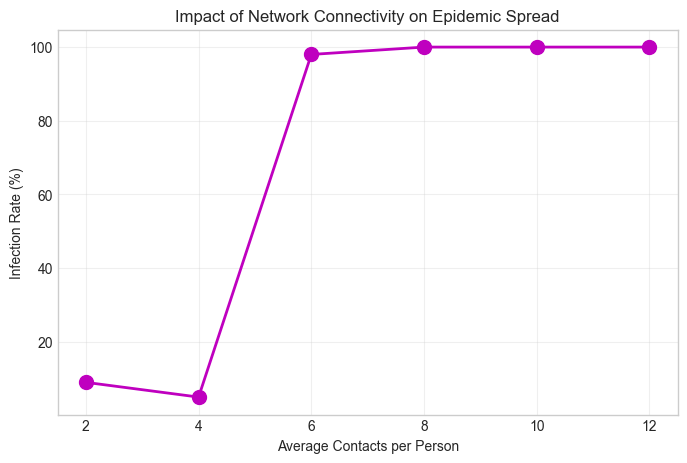

In [ ]:
# Sensitivity: Network connectivity
contacts = [2, 4, 6, 8, 10, 12]
network_results = run_sensitivity('network.avg_contacts', contacts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['value'] for r in network_results], [r['infection_rate'] for r in network_results], 'mo-', linewidth=2, markersize=10)
ax.set_xlabel('Average Contacts per Person')
ax.set_ylabel('Infection Rate (%)')
ax.set_title('Impact of Network Connectivity on Epidemic Spread')
ax.grid(True, alpha=0.3)
plt.show()

---
## 7. Scenario Comparison

Compare different pre-built scenarios.

In [ ]:
# Run different scenarios
scenarios = {
    'Baseline': SimulationConfig(random_seed=42),
    'High Transmission': high_transmission_config(),
    'Low Resources': low_resources_config(),
    'Elderly Population': elderly_population_config(),
    'Dense Network': dense_network_config(),
}

# Set seeds for reproducibility
for cfg in scenarios.values():
    cfg.random_seed = 42

scenario_results = {name: run_simulation(cfg) for name, cfg in scenarios.items()}

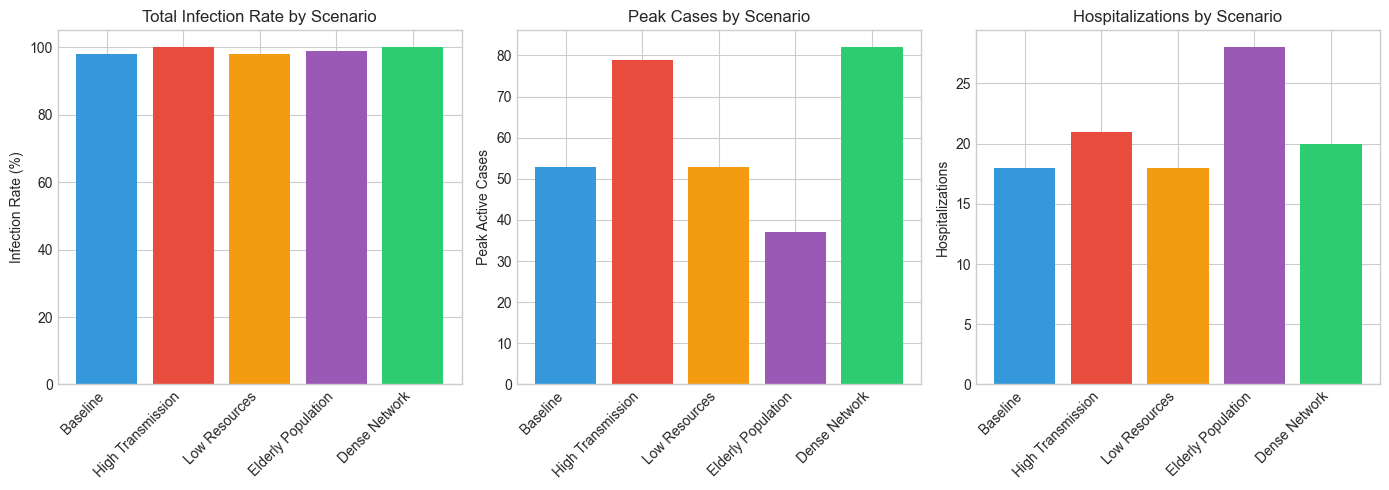

In [ ]:
# Compare scenarios
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

names = list(scenario_results.keys())
infection_rates = [scenario_results[n].infection_rate for n in names]
peak_cases = [scenario_results[n].peak_active_cases for n in names]
hospitalizations = [scenario_results[n].total_hospitalizations for n in names]

x = np.arange(len(names))
colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#2ecc71']

ax1 = axes[0]
bars1 = ax1.bar(x, infection_rates, color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha='right')
ax1.set_ylabel('Infection Rate (%)')
ax1.set_title('Total Infection Rate by Scenario')

ax2 = axes[1]
bars2 = ax2.bar(x, peak_cases, color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=45, ha='right')
ax2.set_ylabel('Peak Active Cases')
ax2.set_title('Peak Cases by Scenario')

ax3 = axes[2]
bars3 = ax3.bar(x, hospitalizations, color=colors)
ax3.set_xticks(x)
ax3.set_xticklabels(names, rotation=45, ha='right')
ax3.set_ylabel('Hospitalizations')
ax3.set_title('Hospitalizations by Scenario')

plt.tight_layout()
plt.show()

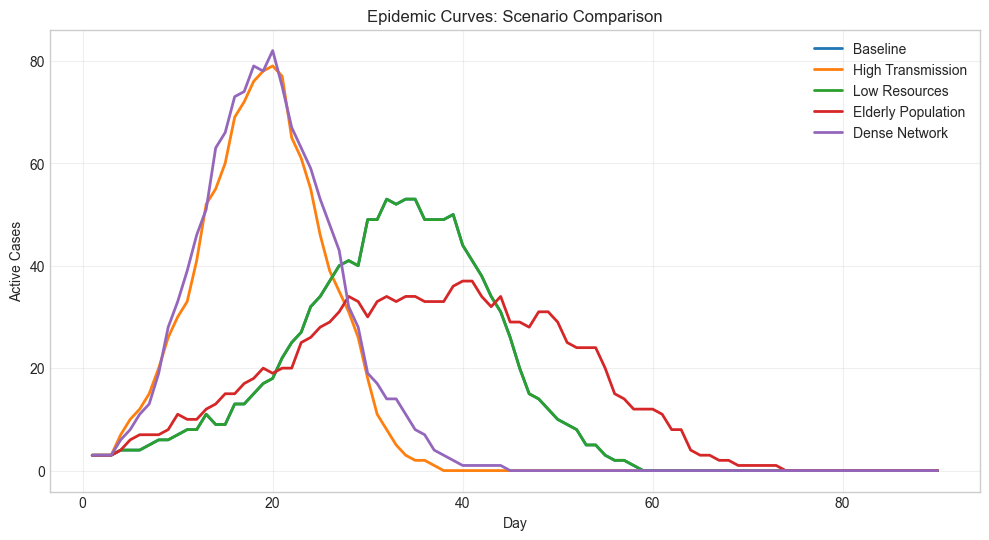

In [ ]:
# Epidemic curves comparison
fig, ax = plt.subplots(figsize=(12, 6))

for name, result in scenario_results.items():
    days = [s['time'] for s in result.daily_snapshots]
    active = [s['active_cases'] for s in result.daily_snapshots]
    ax.plot(days, active, linewidth=2, label=name)

ax.set_xlabel('Day')
ax.set_ylabel('Active Cases')
ax.set_title('Epidemic Curves: Scenario Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 8. Custom Configuration Playground

Modify any parameters and run your own experiments.

In [ ]:
# Create a custom configuration
custom = SimulationConfig(
    random_seed=123,
    duration_days=120,
    initial_infections=5,
)

# Modify disease parameters
custom.disease.transmission_prob = 0.20
custom.disease.hospitalization_prob = 0.10
custom.disease.mortality_prob = 0.05

# Modify network
custom.network.n_people = 200
custom.network.avg_contacts = 8

# Modify supply chain
custom.supply_chain.healthcare_workers = 15
custom.supply_chain.initial_ppe = 500

print(custom.summary())


╔══════════════════════════════════════════════════════════════╗
║                    SIMULATION CONFIGURATION                   ║
╠══════════════════════════════════════════════════════════════╣
║ POPULATION                                                    ║
║   People:  200  │  Age range: 18-80                  ║
║   Avg contacts: 8  │  Rewire prob: 30.0%                ║
╠══════════════════════════════════════════════════════════════╣
║ DISEASE PARAMETERS                                            ║
║   Transmission prob: 20.0%                                 ║
║   Exposure period: 3.0 days                                ║
║   Infectious period: 2.0 days                              ║
║   Symptomatic period: 7.0 days                             ║
║   Hospitalization: 10.0%  │  Mortality: 5.0%         ║
║   Age risk threshold: 60  │  Multiplier: 2.0x          ║
╠══════════════════════════════════════════════════════════════╣
║ SUPPLY CHAIN                                          

In [ ]:
# Run custom simulation
custom_result = run_simulation(custom)
print(custom_result.summary())


╔══════════════════════════════════════════════════════════════╗
║                     SIMULATION RESULTS                        ║
╠══════════════════════════════════════════════════════════════╣
║ EPIDEMIC OUTCOMES                                             ║
║   Total infected:  200 (100.0% of population)           ║
║   Peak active cases:  134 (day 24)                        ║
║   Hospitalizations:   21 (10.5% of infected)          ║
║   Deaths:    0 (0.0% CFR)                              ║
║   Recoveries:  200                                          ║
╠══════════════════════════════════════════════════════════════╣
║ FINAL STATE                                                   ║
║   Susceptible:    0  │  Recovered:  200  │  Deceased:    0  ║
╠══════════════════════════════════════════════════════════════╣
║ SUPPLY CHAIN                                                  ║
║   Final PPE:  21375  │  Min PPE:    500                   ║
║   Final Reagents:  36158  │  Min Reagents:  

---
## 9. Social Network Visualization

In [ ]:
# Create a small network for visualization
small_config = NetworkConfig(n_people=30, avg_contacts=4)
network = SocialNetwork(small_config)

# Get statistics
stats = network.get_statistics()
print(f"Network Statistics:")
print(f"  People: {stats['n_people']}")
print(f"  Avg contacts: {stats['avg_contacts']:.1f}")
print(f"  Min contacts: {stats['min_contacts']}")
print(f"  Max contacts: {stats['max_contacts']}")
print(f"\nAge Distribution:")
print(f"  Range: {stats['age_distribution']['min']}-{stats['age_distribution']['max']}")
print(f"  Mean: {stats['age_distribution']['mean']:.1f}")
print(f"  Elderly (60+): {stats['age_distribution']['elderly_count']} ({stats['age_distribution']['elderly_pct']:.1f}%)")

Network Statistics:
  People: 30
  Avg contacts: 4.0
  Min contacts: 3
  Max contacts: 6

Age Distribution:
  Range: 20-80
  Mean: 52.3
  Elderly (60+): 13 (43.3%)


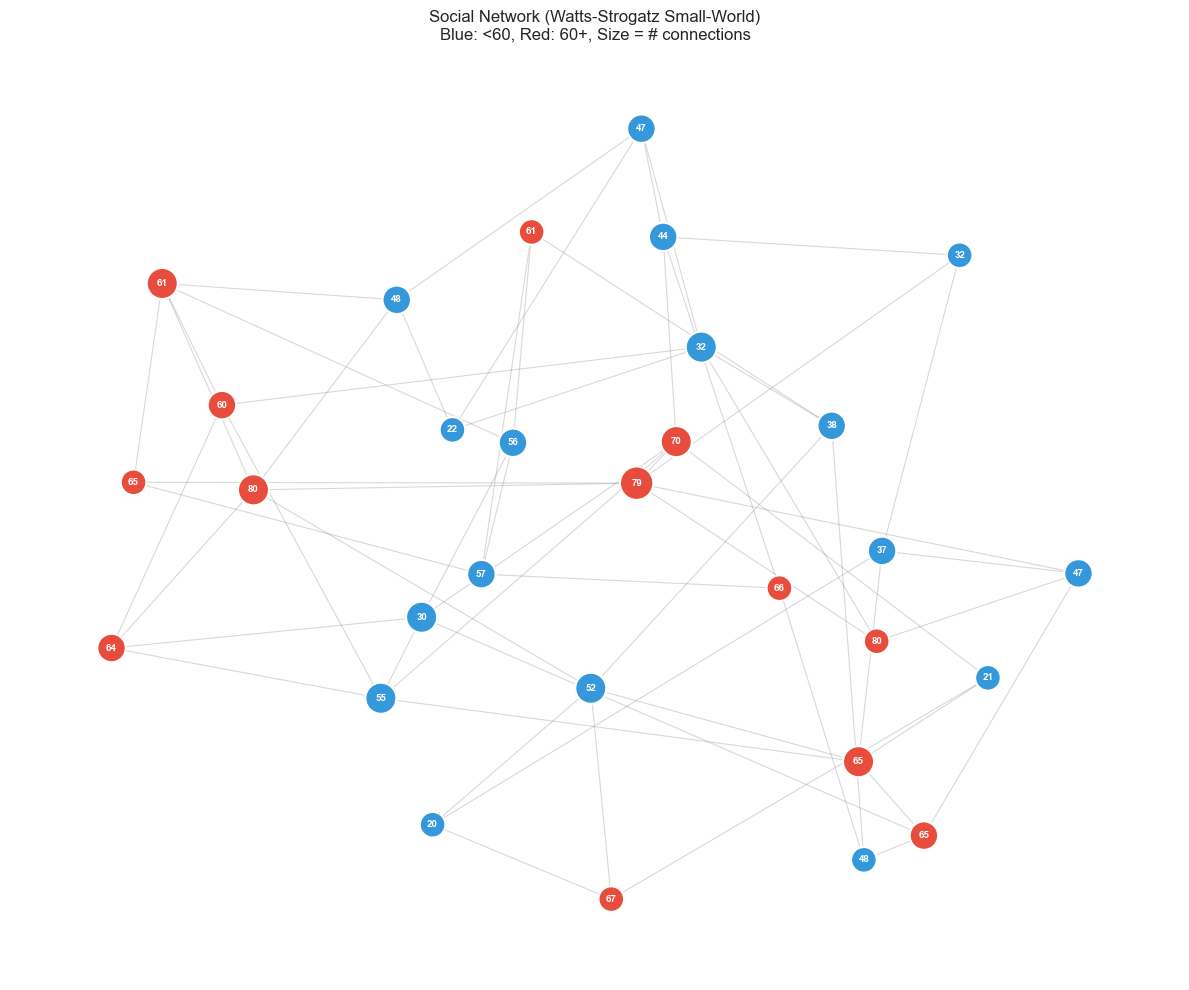


Network Metrics:
  Nodes: 30
  Edges: 60
  Avg clustering coefficient: 0.158
  Avg shortest path: 2.52


In [ ]:
# Social Network Visualization using NetworkX
import networkx as nx

# Build NetworkX graph from our network
G = nx.Graph()
for person in network.people.values():
    G.add_node(person.id, age=person.age)
    for contact_id in person.contacts:
        if contact_id > person.id:
            G.add_edge(person.id, contact_id)

# Use spring layout (Fruchterman-Reingold) - much better for social networks
pos = nx.spring_layout(G, k=2, iterations=100, seed=42)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

# Draw edges first
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, edge_color='gray', ax=ax)

# Draw nodes - color by age, size by degree (connections)
node_colors = ['#e74c3c' if network.people[n].age >= 60 else '#3498db' for n in G.nodes()]
node_sizes = [100 + G.degree(n) * 80 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                        edgecolors='white', linewidths=1.5, ax=ax)

# Add age labels
labels = {n: str(network.people[n].age) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_color='white', 
                         font_weight='bold', ax=ax)

ax.set_title('Social Network (Watts-Strogatz Small-World)\nBlue: <60, Red: 60+, Size = # connections', 
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# Show network metrics
print(f"\nNetwork Metrics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Avg clustering coefficient: {nx.average_clustering(G):.3f}")
print(f"  Avg shortest path: {nx.average_shortest_path_length(G):.2f}")

---
## 10. Monte Carlo Analysis

Run multiple simulations to understand variability.

In [ ]:
# Run 20 simulations with different seeds
n_runs = 20
monte_carlo_results = []

for i in range(n_runs):
    cfg = SimulationConfig(random_seed=i*100)
    result = run_simulation(cfg)
    monte_carlo_results.append({
        'seed': i*100,
        'infection_rate': result.infection_rate,
        'peak_cases': result.peak_active_cases,
        'peak_day': result.peak_day,
        'hospitalizations': result.total_hospitalizations,
        'deaths': result.total_deaths,
    })

# Summary statistics
infection_rates = [r['infection_rate'] for r in monte_carlo_results]
peak_cases = [r['peak_cases'] for r in monte_carlo_results]
peak_days = [r['peak_day'] for r in monte_carlo_results]

print(f"Monte Carlo Results ({n_runs} runs):")
print(f"\nInfection Rate:")
print(f"  Mean: {np.mean(infection_rates):.1f}%")
print(f"  Std: {np.std(infection_rates):.1f}%")
print(f"  Range: {min(infection_rates):.1f}% - {max(infection_rates):.1f}%")

print(f"\nPeak Active Cases:")
print(f"  Mean: {np.mean(peak_cases):.1f}")
print(f"  Std: {np.std(peak_cases):.1f}")
print(f"  Range: {min(peak_cases)} - {max(peak_cases)}")

print(f"\nPeak Day:")
print(f"  Mean: {np.mean(peak_days):.1f}")
print(f"  Std: {np.std(peak_days):.1f}")
print(f"  Range: {min(peak_days):.0f} - {max(peak_days):.0f}")

Monte Carlo Results (20 runs):

Infection Rate:
  Mean: 97.5%
  Std: 2.5%
  Range: 92.0% - 100.0%

Peak Active Cases:
  Mean: 41.7
  Std: 7.0
  Range: 25 - 54

Peak Day:
  Mean: 35.5
  Std: 8.1
  Range: 25 - 60


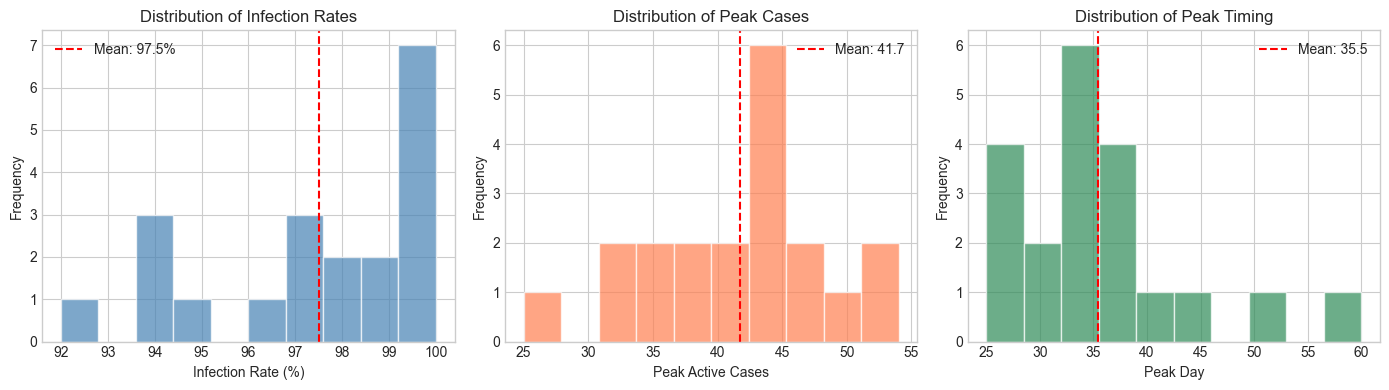

In [ ]:
# Visualize Monte Carlo results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
ax1.hist(infection_rates, bins=10, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(x=np.mean(infection_rates), color='red', linestyle='--', label=f'Mean: {np.mean(infection_rates):.1f}%')
ax1.set_xlabel('Infection Rate (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Infection Rates')
ax1.legend()

ax2 = axes[1]
ax2.hist(peak_cases, bins=10, color='coral', edgecolor='white', alpha=0.7)
ax2.axvline(x=np.mean(peak_cases), color='red', linestyle='--', label=f'Mean: {np.mean(peak_cases):.1f}')
ax2.set_xlabel('Peak Active Cases')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Peak Cases')
ax2.legend()

ax3 = axes[2]
ax3.hist(peak_days, bins=10, color='seagreen', edgecolor='white', alpha=0.7)
ax3.axvline(x=np.mean(peak_days), color='red', linestyle='--', label=f'Mean: {np.mean(peak_days):.1f}')
ax3.set_xlabel('Peak Day')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Peak Timing')
ax3.legend()

plt.tight_layout()
plt.show()